In [14]:
# OpenCV para manipulações de imagens
import cv2
# Numpy para trabalhar com matrizes
import numpy as np
# Matplotlib para plotar imagens
import matplotlib.pyplot as plt

In [15]:
# Filtro de média
mean_filter = (np.zeros((3, 3)) + 1) / 9

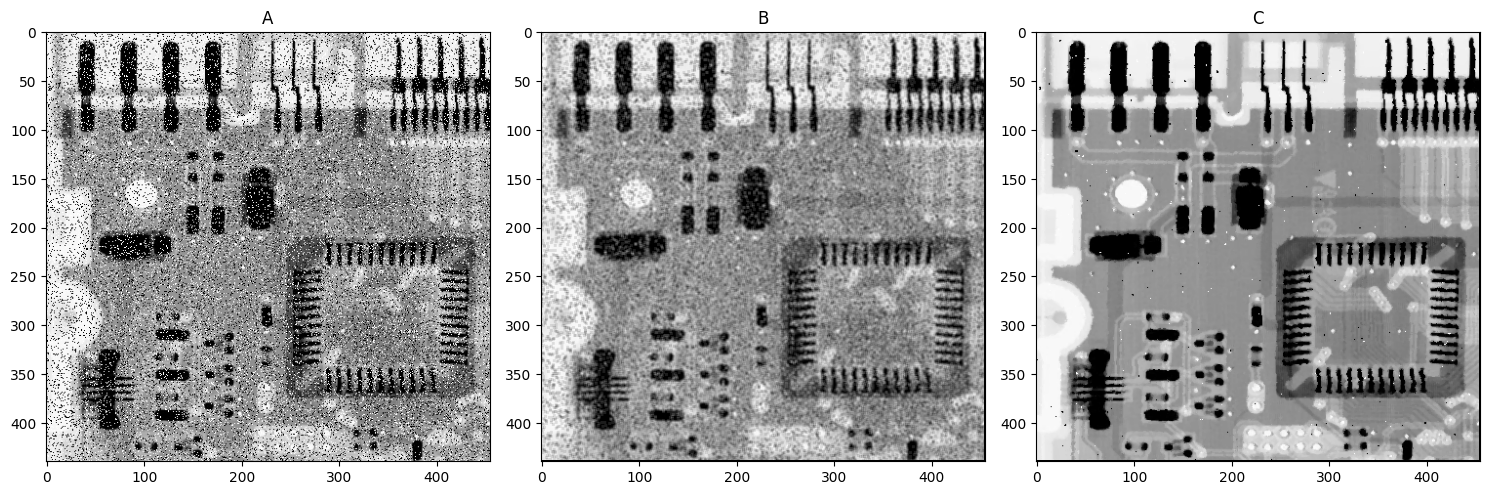

In [16]:
# Array das imagens
images = []

# Lendo a imagem
images.append(cv2.imread("./images/board.tif"))
# Tranformando me escala de cinza
images[0] = cv2.cvtColor(images[0], cv2.COLOR_BGR2GRAY)
# Tranformando seus valores em float64
images[0] = images[0].astype(np.float64)

# Obtendo altura e largura
height = images[0].shape[0]
width = images[0].shape[1]

# Criando a 2 imagem
images.append(np.zeros(images[0].shape))
aux = np.pad(images[0], pad_width = 1, mode = "constant", constant_values = 0)

# Aplicando o filto de média
for i in range(1, height):
  for j in range(1, width):
    images[1][i - 1][j - 1] = np.sum(aux[i - 1: i + 2, j - 1: j + 2] * mean_filter)

# Criando a 3 imagem
images.append(np.zeros(images[0].shape))

# Aplicando o filto de mediana
for i in range(1, height):
  for j in range(1, width):
    images[2][i - 1][j - 1] = np.median(aux[i - 1: i + 2, j - 1: j + 2])

# Convertendo em RGB
for i in range(3):
  images[i] = cv2.cvtColor(images[i].astype(np.uint8), cv2.COLOR_GRAY2RGB)

# Criando uma matriz 1 x 3 para o plot\n"
fig, axs = plt.subplots(1, 3, figsize = (15, 5))
# Organizando as imagens na matriz 2 x 3 do plot\n",
for j in range(3):
  axs[j].imshow(images[j])
  axs[j].set_title(chr(ord('A') + j))
# Evitando sobreposição das imagens no plot\n",
plt.tight_layout()
# Salvando um cópia do plot\n",
fig.savefig('./images/board-out.png', dpi = 300, bbox_inches = 'tight')
# Exibindo o plot\n",
plt.show()